# 01 - Two-Node Elementary Entanglement

## Objetivo
Demonstrar geração elementar de entrelaçamento entre dois `QuantumRouter`
ligados por um nó BSM, usando o `ibqn.execution.SequenceExecutor` real (não
uma simulação simplificada), e mostrar reprodutibilidade por seed.

## Conceitos
- `ibqn.network.topology.NetworkTopologySpec` descreve a topologia (nós +
  links quânticos); `SequenceAdapter` a traduz para um `RouterNetTopo` real
  do SeQUeNCe, que gera automaticamente o nó BSM no ponto médio do link
  (`meet_in_the_middle`) - ver `docs/sequence_code_analysis.md`, seção 4.6.
- Sem repetidor entre os dois roteadores, o intent só exercita geração
  elementar - não há swapping nem purificação. No formalismo padrão
  (`bell_diagonal`, `docs/physical_model.md`) a geração usa o protocolo
  *single-heralded* do SeQUeNCe, o único que escreve estados
  Bell-diagonais: cada par nasce com fidelidade `raw_fidelity`, e a
  fidelidade reportada é lida do estado armazenado.
- Cada par entregue é identificado por um evento `EventTypes.DELIVERY`
  tagueado com o `intent_id`, nunca por `entangle_time > 0`
  (`docs/assurance_design.md`, seção 6).
- `sequence.utils.metrics` é um singleton de processo
  (`docs/sequence_code_analysis.md`, seção 4.1): sempre que este notebook
  roda mais de uma simulação independente no mesmo kernel, cada rodada
  chama `metrics.configure()` primeiro (o mesmo padrão usado por
  `ibqn.experiments.runner.run_scenario`) para começar de um `storage`
  vazio - sem isso, registros de uma rodada anterior vazariam para a
  próxima e invalidariam qualquer comparação entre elas.


## Configuração


In [1]:
from sequence.utils import metrics
from ibqn.demos.topologies import two_node_spec
from ibqn.network.sequence_adapter import SequenceAdapter
from ibqn.execution.sequence_executor import SequenceExecutor
from ibqn.intent.repository import IntentRepository
from ibqn.intent.models import (
    EntanglementIntent, IntentEndpoints, IntentRequirements, IntentValidation, SuccessCondition,
)

SEED = 0
REQUESTED_PAIRS = 10
MIN_FIDELITY = 0.65  # dimensionless, in [0, 1]

spec = two_node_spec(memories=REQUESTED_PAIRS, distance_m=1000, attenuation_db_per_m=1e-4)

intent = EntanglementIntent(
    id="intent-two-node-demo",
    endpoints=IntentEndpoints(source="a", destination="b"),
    requirements=IntentRequirements(
        min_fidelity=MIN_FIDELITY, min_throughput=1, max_latency=1.0,
        requested_pairs=REQUESTED_PAIRS, start_time=0.02, duration=0.1,
    ),
    validation=IntentValidation(
        metrics=["delivered_pairs", "average_fidelity"],
        success_conditions=[
            SuccessCondition(metric="delivered_pairs", operator=">=", expected=REQUESTED_PAIRS),
            SuccessCondition(metric="average_fidelity", operator=">=", expected=MIN_FIDELITY),
        ],
    ),
)
intent


2026-10-02 15:03:07,055 INFO     ibqn.ibqn.intent.models intent_id=- - IntentRequirements: migrating legacy field 'requested_pairs' -> 'reserved_memory_slots' (see docs/intent_resource_semantics.md)


2026-10-02 15:03:07,063 INFO     ibqn.ibqn.intent.models intent_id=- - IntentRequirements: migrating legacy field 'start_time' -> 'start_time_s' (see docs/intent_resource_semantics.md)


2026-10-02 15:03:07,067 INFO     ibqn.ibqn.intent.models intent_id=- - IntentRequirements: migrating legacy field 'duration' -> 'duration_s' (see docs/intent_resource_semantics.md)


EntanglementIntent(id='intent-two-node-demo', service='entanglement_distribution', endpoints=IntentEndpoints(source='a', destination='b'), requirements=IntentRequirements(min_fidelity=0.65, min_throughput=1.0, max_latency=1.0, min_delivered_pairs=None, reserved_memory_slots=10, start_time_s=0.02, duration_s=0.1), policy=IntentPolicy(priority='normal', allow_rerouting=True, allow_purification=True, allow_multiple_paths=False), validation=IntentValidation(metrics=['delivered_pairs', 'average_fidelity'], success_conditions=[SuccessCondition(metric='delivered_pairs', operator='>=', expected=10.0), SuccessCondition(metric='average_fidelity', operator='>=', expected=0.65)]))

## Execução


In [2]:
metrics.configure()  # fresh storage: this is the first simulation run in this kernel

adapter = SequenceAdapter(spec, seed=SEED)
repository = IntentRepository()
executor = SequenceExecutor(adapter, repository)

executor.submit(intent)
executor.run()

repository.get(intent.id).lifecycle.status


2026-10-02 15:03:07,104 INFO     ibqn.ibqn.network.sequence_adapter intent_id=- - topology built: 2 routers, 1 quantum links, formalism=bell_diagonal, seed=0


2026-10-02 15:03:07,106 INFO     ibqn.ibqn.intent.repository intent_id=intent-two-node-demo - intent registered


2026-10-02 15:03:07,108 INFO     ibqn.ibqn.intent.repository intent_id=intent-two-node-demo - intent transitioned to VALIDATED (schema validated)


2026-10-02 15:03:07,109 INFO     ibqn.ibqn.intent.repository intent_id=intent-two-node-demo - intent transitioned to PLANNING (no planner used: delegating route/purification decisions to SeQUeNCe's default reservation mechanism)


2026-10-02 15:03:07,111 INFO     ibqn.ibqn.intent.repository intent_id=intent-two-node-demo - intent transitioned to PLANNED (trivial pass-through plan)


2026-10-02 15:03:07,112 INFO     ibqn.ibqn.intent.repository intent_id=intent-two-node-demo - intent transitioned to DEPLOYING (submitting reservation to NetworkManager)


2026-10-02 15:03:07,114 INFO     ibqn.ibqn.execution.sequence_executor intent_id=intent-two-node-demo - submitting reservation a -> b, reserved_memory_slots=10, min_fidelity=0.650, purification_mode=until_target


2026-10-02 15:03:07,116 INFO     ibqn.ibqn.network.sequence_adapter intent_id=- - running simulation, stop_time=0.100s


2026-10-02 15:03:07,119 INFO     ibqn.ibqn.intent.repository intent_id=intent-two-node-demo - intent transitioned to ACTIVE (reservation approved)


<IntentStatus.ACTIVE: 'ACTIVE'>

## Resultados


In [3]:
from ibqn.assurance.telemetry import collect_intent_evidence
from ibqn.demos.tables import delivered_pairs_table

evidence = collect_intent_evidence(intent)
pairs_df = delivered_pairs_table(evidence)
pairs_df.head(10)


,pair,local_memory,remote_memory,delivery_time_s,fidelity
0,1,a.MemoryArray[0],b.MemoryArray[0],0.020353,0.85
1,2,a.MemoryArray[6],b.MemoryArray[6],0.020353,0.85
2,3,a.MemoryArray[1],b.MemoryArray[1],0.020705,0.85
3,4,a.MemoryArray[5],b.MemoryArray[5],0.020705,0.85
4,5,a.MemoryArray[9],b.MemoryArray[9],0.020705,0.85
5,6,a.MemoryArray[0],b.MemoryArray[0],0.021058,0.85
6,7,a.MemoryArray[9],b.MemoryArray[9],0.021058,0.85
7,8,a.MemoryArray[4],b.MemoryArray[4],0.021410,0.85
8,9,a.MemoryArray[1],b.MemoryArray[1],0.022115,0.85
9,10,a.MemoryArray[7],b.MemoryArray[7],0.022115,0.85


In [4]:
print(f"delivered pairs: {len(evidence.delivered_pairs)} (requested: {REQUESTED_PAIRS})")
print(f"average fidelity (dimensionless): {pairs_df['fidelity'].mean():.4f}")
print(f"first delivery time (s): {pairs_df['delivery_time_s'].min():.6f}")
print(f"last delivery time (s): {pairs_df['delivery_time_s'].max():.6f}")


delivered pairs: 389 (requested: 10)
average fidelity (dimensionless): 0.8500
first delivery time (s): 0.020353
last delivery time (s): 0.099668


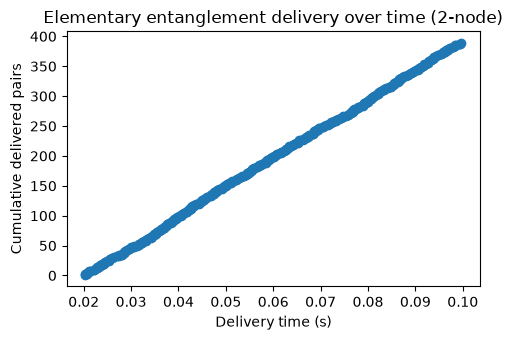

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(pairs_df["delivery_time_s"], pairs_df["pair"], marker="o")
ax.set_xlabel("Delivery time (s)")
ax.set_ylabel("Cumulative delivered pairs")
ax.set_title("Elementary entanglement delivery over time (2-node)")
fig.tight_layout()
plt.show()


### Reprodutibilidade por seed

Rodar o mesmo cenário duas vezes com a mesma seed deve produzir exatamente
os mesmos tempos de entrega. Cada rodada chama `metrics.configure()` antes
de construir seu próprio `SequenceAdapter`/`SequenceExecutor`, para que a
segunda rodada não leia registros deixados pela primeira (`storage` é um
singleton de processo, não por-simulação).


In [6]:
def run_once(seed):
    metrics.configure()  # fresh storage for this independent run
    adapter_ = SequenceAdapter(spec, seed=seed)
    repository_ = IntentRepository()
    executor_ = SequenceExecutor(adapter_, repository_)
    executor_.submit(intent)
    executor_.run()
    return collect_intent_evidence(intent)

evidence_a = run_once(SEED)
evidence_b = run_once(SEED)
times_a = [p.sim_time_s for p in evidence_a.delivered_pairs]
times_b = [p.sim_time_s for p in evidence_b.delivered_pairs]
assert len(times_a) > 0, "sanity check: the run must actually deliver pairs"
assert times_a == times_b, "same seed must reproduce identical delivery times"
print(f"Reproducibility confirmed: {len(times_a)} identical delivery times across two independent runs with seed={SEED}.")


2026-10-02 15:03:10,319 INFO     ibqn.ibqn.network.sequence_adapter intent_id=- - topology built: 2 routers, 1 quantum links, formalism=bell_diagonal, seed=0


2026-10-02 15:03:10,321 INFO     ibqn.ibqn.intent.repository intent_id=intent-two-node-demo - intent registered


2026-10-02 15:03:10,322 INFO     ibqn.ibqn.intent.repository intent_id=intent-two-node-demo - intent transitioned to VALIDATED (schema validated)


2026-10-02 15:03:10,324 INFO     ibqn.ibqn.intent.repository intent_id=intent-two-node-demo - intent transitioned to PLANNING (no planner used: delegating route/purification decisions to SeQUeNCe's default reservation mechanism)


2026-10-02 15:03:10,325 INFO     ibqn.ibqn.intent.repository intent_id=intent-two-node-demo - intent transitioned to PLANNED (trivial pass-through plan)


...

2026-10-02 15:03:12,538 INFO     ibqn.ibqn.intent.repository intent_id=intent-two-node-demo - intent transitioned to DEPLOYING (submitting reservation to NetworkManager)


2026-10-02 15:03:12,540 INFO     ibqn.ibqn.execution.sequence_executor intent_id=intent-two-node-demo - submitting reservation a -> b, reserved_memory_slots=10, min_fidelity=0.650, purification_mode=until_target


2026-10-02 15:03:12,541 INFO     ibqn.ibqn.network.sequence_adapter intent_id=- - running simulation, stop_time=0.100s


2026-10-02 15:03:12,543 INFO     ibqn.ibqn.intent.repository intent_id=intent-two-node-demo - intent transitioned to ACTIVE (reservation approved)


Reproducibility confirmed: 389 identical delivery times across two independent runs with seed=0.


## Interpretação
Toda linha da tabela acima vem de um evento `DELIVERY` real, gerado por
`IntentRequestApp.get_memory` a partir do estado observado de uma
`MemoryInfo` do SeQUeNCe (nunca calculado fora da simulação). A fidelidade
observada é igual à `raw_fidelity` configurada (`NodeSpec.raw_fidelity`,
padrão 0.85) em todos os pares: neste cenário de 2 nós não há swap nem
purificação, e cada par é entregue no instante em que é anunciado, antes
que a decoerência da memória (tempo de coerência de 1 s por padrão) atue.
Com um repetidor isso deixa de valer: os pares esperam e decoerem (ver o
notebook 02).

## Limitações
- Sem repetidor, este notebook não demonstra swapping/purificação (ver
  `02_sequence_three_node_swapping.ipynb` e `03_sequence_purification.ipynb`).
- `requested_pairs` funciona como tamanho do pool de memórias, não como
  teto de entrega - mais pares que o solicitado podem ser entregues dado
  tempo suficiente (`docs/sequence_integration.md`); a tabela mostra apenas
  as primeiras 10 linhas.
- `sequence.utils.metrics.storage` é um singleton de processo: qualquer
  código que rode mais de uma simulação no mesmo kernel deve chamar
  `metrics.configure()` entre rodadas (como feito acima), ou registros de
  DELIVERY de rodadas antigas vazam para a coleta de evidência seguinte e
  são silenciosamente deduplicados por `pair_number` - um comportamento
  documentado aqui porque foi observado durante a construção deste próprio
  notebook antes desta correção.

## Conclusão
Geração elementar demonstrada de ponta a ponta através de
`ibqn.execution.SequenceExecutor`, com tabela de pares reais entregues e
reprodutibilidade por seed confirmada entre duas rodadas genuinamente
independentes.
